In [1]:

# ============================================================
# Homework 1 - RTML (ECGR-4106/5106)
# Modified AlexNet, VGGNet, and ResNet on CIFAR-10
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time
import random
from torchsummary import summary

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Random seed: {SEED}')

Using device: cuda
Random seed: 42


In [2]:

# ============================================================
# Data Loading & Augmentation (shared across all problems)
# ============================================================

# CIFAR-10 normalization constants (mean and std for R,G,B)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=train_transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=test_transform)

# Split train into 45k train / 5k validation
train_size = 45000
val_size   = 5000
train_set, val_set = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Override val set transform to test_transform (no augmentation)
val_set.dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=False, transform=test_transform)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}')
print(f'Batch size: {BATCH_SIZE}')

100%|██████████| 170M/170M [00:51<00:00, 3.30MB/s]


Train: 45000, Val: 5000, Test: 10000
Batch size: 128


In [3]:

# ============================================================
# Utility Functions: training loop, eval, plotting
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)
    return total_loss / total, 100.0 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += inputs.size(0)
    return total_loss / total, 100.0 * correct / total

def get_all_preds(model, loader, device):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.numpy())
    return np.array(all_preds), np.array(all_labels)

def plot_curves(train_losses, val_losses, val_accs, title, labels=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)
    if labels is None:
        labels = [f'run {i}' for i in range(len(train_losses))]
    for i, (tl, vl, va) in enumerate(zip(train_losses, val_losses, val_accs)):
        epochs = range(1, len(tl)+1)
        ax1.plot(epochs, tl, linestyle='--', label=f'{labels[i]} train')
        ax1.plot(epochs, vl, label=f'{labels[i]} val')
        ax2.plot(epochs, va, label=labels[i])
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curves'); ax1.legend()
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Val Accuracy'); ax2.legend()
    plt.tight_layout(); plt.show()

def plot_confusion_matrix(preds, labels, classes, title):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title); plt.tight_layout(); plt.show()

def visualize_first_layer_filters(model, first_conv_attr, title):
    conv = first_conv_attr
    filters = conv.weight.data.cpu().clone()
    # Normalize per filter
    n_filters = min(filters.shape[0], 32)
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    fig.suptitle(title)
    for idx, ax in enumerate(axes.flat):
        if idx < n_filters:
            f = filters[idx]
            f = f - f.min(); f = f / (f.max() + 1e-8)
            if f.shape[0] == 3:
                ax.imshow(f.permute(1,2,0).numpy())
            else:
                ax.imshow(f[0].numpy(), cmap='gray')
        ax.axis('off')
    plt.tight_layout(); plt.show()

def train_model(model, train_loader, val_loader, n_epochs, lr=0.01,
                weight_decay=5e-4, scheduler_type='cosine', device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                          weight_decay=weight_decay)
    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    else:
        scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                                    milestones=[int(n_epochs*0.5), int(n_epochs*0.75)],
                                                    gamma=0.1)
    train_losses, val_losses, val_accs = [], [], []
    best_val_acc = 0.0
    start = time.time()
    for epoch in range(1, n_epochs+1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        train_losses.append(t_loss); val_losses.append(v_loss); val_accs.append(v_acc)
        if v_acc > best_val_acc:
            best_val_acc = v_acc
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{n_epochs} | '
                  f'T-Loss: {t_loss:.4f} T-Acc: {t_acc:.2f}% | '
                  f'V-Loss: {v_loss:.4f} V-Acc: {v_acc:.2f}%')
    elapsed = time.time() - start
    print(f'\nTraining complete in {elapsed/60:.1f} min | Best Val Acc: {best_val_acc:.2f}%')
    print(f'Time per epoch: {elapsed/n_epochs:.1f}s')
    return train_losses, val_losses, val_accs, elapsed

print('Utility functions defined.')

Utility functions defined.


In [4]:

# ============================================================
# PROBLEM 1A: Modified AlexNet for CIFAR-10 (32x32)
# ============================================================
# Modifications vs. original AlexNet (227x227, 61M params):
# 1. First conv: 11x11 stride 4 -> 3x3 stride 1 (32x32 spatial dims preserved)
# 2. Removed first MaxPool (would collapse 32x32 too early)
# 3. Conv2: 5x5 -> 3x3
# 4. Only 1 MaxPool after Conv2 (stride 2), plus 1 after Conv5
# 5. FC layers: 4096->4096->1000 -> 1024->512->10 (drastically fewer params)
# 6. Filter counts halved throughout

class ModifiedAlexNet(nn.Module):
    def __init__(self, dropout_p=0.0):
        super(ModifiedAlexNet, self).__init__()
        self.features = nn.Sequential(
            # Block 1: 32->32
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # 32x32
            nn.ReLU(inplace=True),
            # Block 2: 32->16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),            # 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # 16x16
            # Block 3: 16->16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),           # 16x16
            nn.ReLU(inplace=True),
            # Block 4: 16->16
            nn.Conv2d(128, 128, kernel_size=3, padding=1),          # 16x16
            nn.ReLU(inplace=True),
            # Block 5: 16->8
            nn.Conv2d(128, 64, kernel_size=3, padding=1),           # 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(64 * 8 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Instantiate baseline (no dropout)
alexnet_base = ModifiedAlexNet(dropout_p=0.0).to(device)
print('=== Modified AlexNet (Baseline, no dropout) ===')
summary(alexnet_base, (3, 32, 32))
print(f'\nOriginal AlexNet params: ~61,100,840')

=== Modified AlexNet (Baseline, no dropout) ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          18,496
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6          [-1, 128, 16, 16]          73,856
              ReLU-7          [-1, 128, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]         147,584
              ReLU-9          [-1, 128, 16, 16]               0
           Conv2d-10           [-1, 64, 16, 16]          73,792
             ReLU-11           [-1, 64, 16, 16]               0
        MaxPool2d-12             [-1, 64, 8, 8]               0
          Dropout-13                 [-1, 4096]        

Training P1A: Modified AlexNet - Baseline (no dropout), 30 epochs
Hyperparams: SGD lr=0.1, momentum=0.9, wd=5e-4, CosineAnnealingLR, batch=128
Epoch   1/30 | T-Loss: 2.1149 T-Acc: 19.82% | V-Loss: 1.8761 V-Acc: 28.10%
Epoch   5/30 | T-Loss: 1.4252 T-Acc: 48.48% | V-Loss: 1.2724 V-Acc: 54.42%
Epoch  10/30 | T-Loss: 1.0101 T-Acc: 64.68% | V-Loss: 0.9940 V-Acc: 65.42%
Epoch  15/30 | T-Loss: 0.7426 T-Acc: 74.17% | V-Loss: 0.6926 V-Acc: 76.38%
Epoch  20/30 | T-Loss: 0.5309 T-Acc: 81.68% | V-Loss: 0.5400 V-Acc: 81.16%
Epoch  25/30 | T-Loss: 0.3591 T-Acc: 87.51% | V-Loss: 0.4134 V-Acc: 85.68%
Epoch  30/30 | T-Loss: 0.2762 T-Acc: 90.49% | V-Loss: 0.3832 V-Acc: 86.86%

Training complete in 2.0 min | Best Val Acc: 86.86%
Time per epoch: 4.1s

P1A Test Accuracy: 87.17%


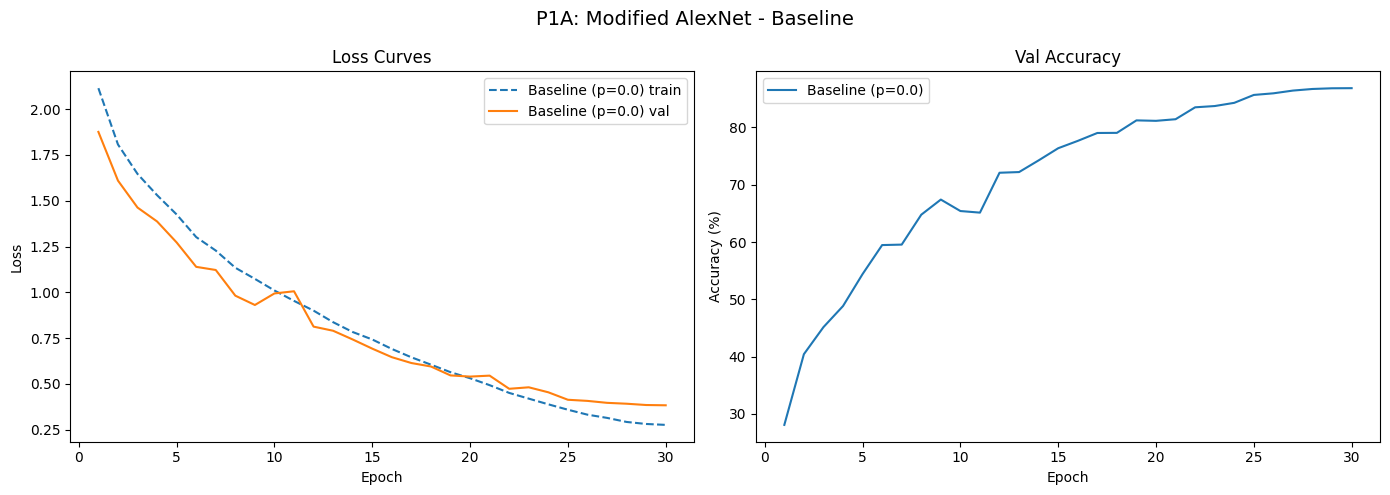

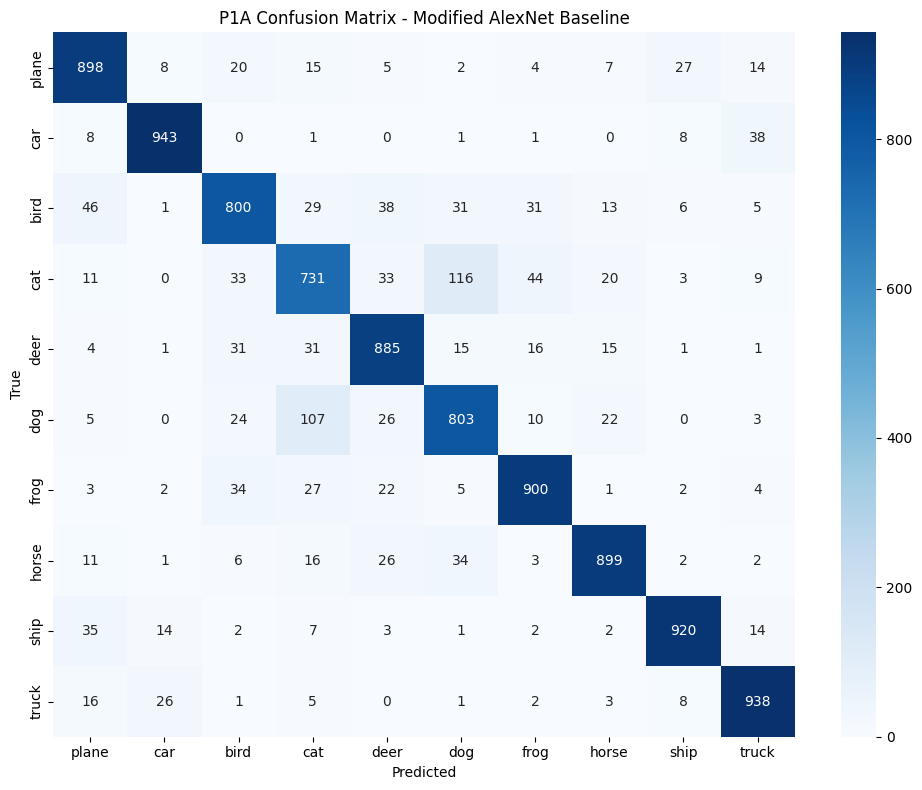

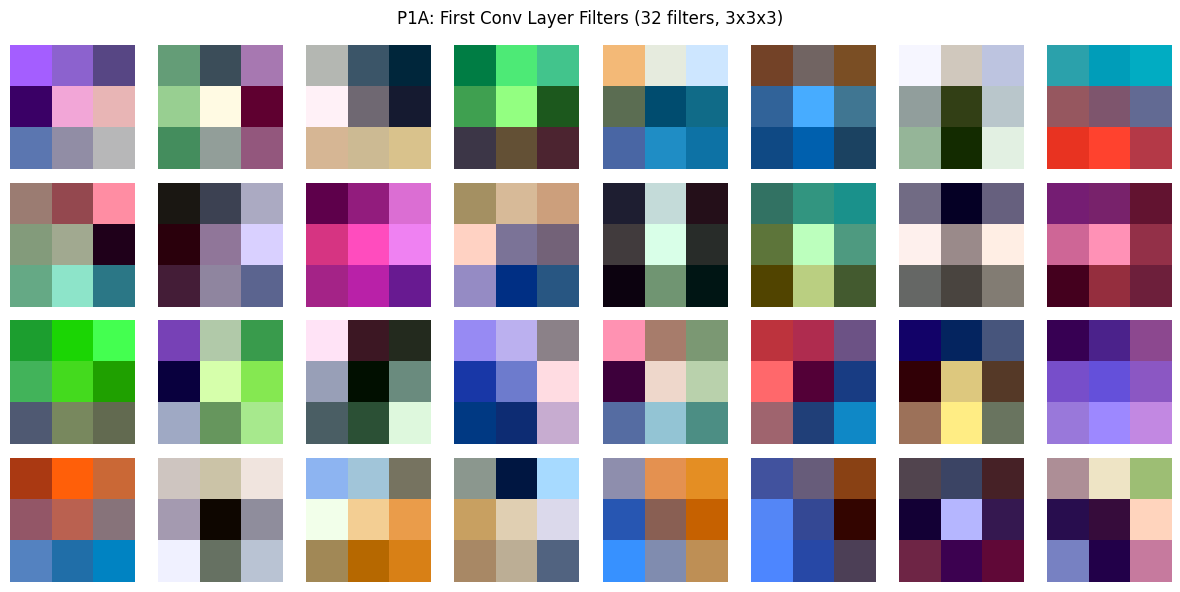

In [5]:

# ============================================================
# PROBLEM 1A: Train baseline AlexNet (30 epochs)
# ============================================================
print('Training P1A: Modified AlexNet - Baseline (no dropout), 30 epochs')
print('Hyperparams: SGD lr=0.1, momentum=0.9, wd=5e-4, CosineAnnealingLR, batch=128')

alexnet_base = ModifiedAlexNet(dropout_p=0.0).to(device)
p1a_tl, p1a_vl, p1a_va, p1a_time = train_model(
    alexnet_base, train_loader, val_loader,
    n_epochs=30, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)

# Test accuracy
crit = nn.CrossEntropyLoss()
_, p1a_test_acc = evaluate(alexnet_base, test_loader, crit, device)
print(f'\nP1A Test Accuracy: {p1a_test_acc:.2f}%')

# Plot curves
plot_curves([p1a_tl], [p1a_vl], [p1a_va],
            'P1A: Modified AlexNet - Baseline', labels=['Baseline (p=0.0)'])

# Confusion matrix
p1a_preds, p1a_labels = get_all_preds(alexnet_base, test_loader, device)
plot_confusion_matrix(p1a_preds, p1a_labels, CLASSES, 'P1A Confusion Matrix - Modified AlexNet Baseline')

# Visualize first-layer filters
visualize_first_layer_filters(alexnet_base, alexnet_base.features[0],
                               'P1A: First Conv Layer Filters (32 filters, 3x3x3)')

Training P1B: Modified AlexNet with Dropout p=0.3
Epoch   1/30 | T-Loss: 2.0453 T-Acc: 22.45% | V-Loss: 1.8080 V-Acc: 30.04%
Epoch   5/30 | T-Loss: 1.4987 T-Acc: 44.96% | V-Loss: 1.3344 V-Acc: 51.04%
Epoch  10/30 | T-Loss: 1.0857 T-Acc: 62.00% | V-Loss: 0.9507 V-Acc: 66.82%
Epoch  15/30 | T-Loss: 0.8315 T-Acc: 71.14% | V-Loss: 0.6895 V-Acc: 76.02%
Epoch  20/30 | T-Loss: 0.6133 T-Acc: 78.76% | V-Loss: 0.5215 V-Acc: 81.64%
Epoch  25/30 | T-Loss: 0.4481 T-Acc: 84.50% | V-Loss: 0.4175 V-Acc: 85.50%
Epoch  30/30 | T-Loss: 0.3720 T-Acc: 86.95% | V-Loss: 0.3763 V-Acc: 87.02%

Training complete in 2.0 min | Best Val Acc: 87.02%
Time per epoch: 4.1s
P1B (p=0.3) Test Acc: 86.82%

Training P1B: Modified AlexNet with Dropout p=0.5
Epoch   1/30 | T-Loss: 2.0859 T-Acc: 20.68% | V-Loss: 1.9310 V-Acc: 27.24%
Epoch   5/30 | T-Loss: 1.7142 T-Acc: 35.12% | V-Loss: 1.5761 V-Acc: 42.22%
Epoch  10/30 | T-Loss: 1.3342 T-Acc: 51.78% | V-Loss: 1.2005 V-Acc: 56.28%
Epoch  15/30 | T-Loss: 1.0204 T-Acc: 64.27% | 

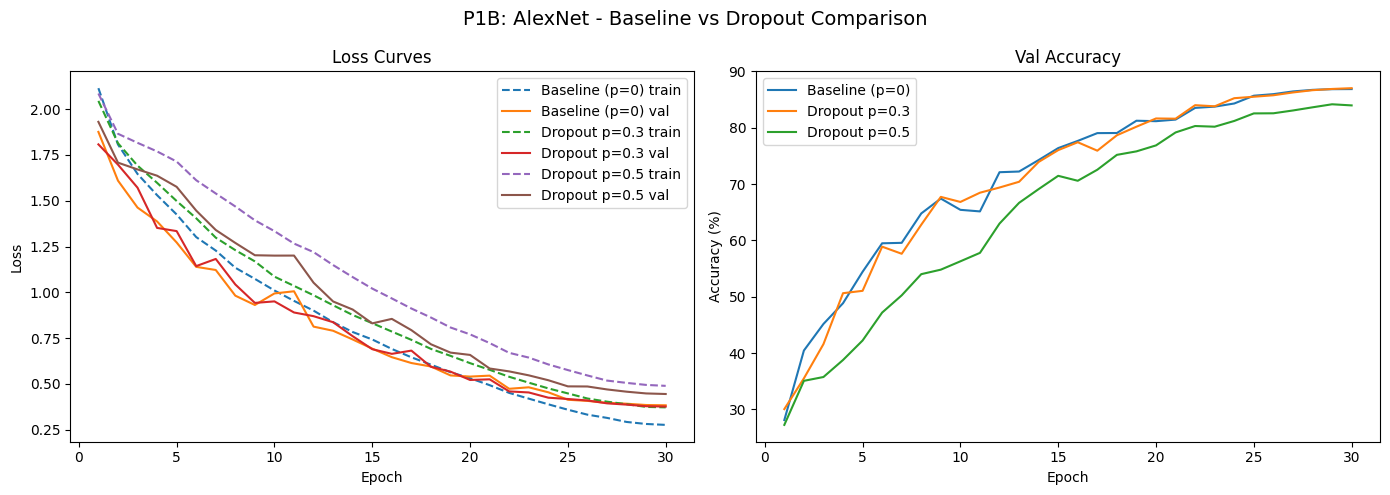

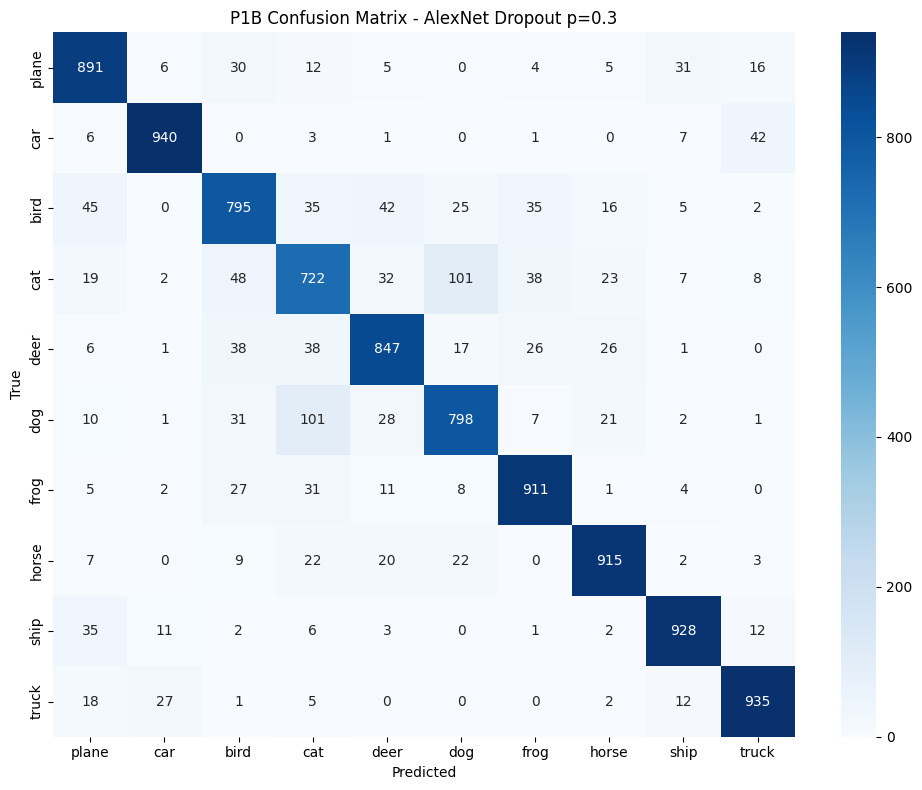

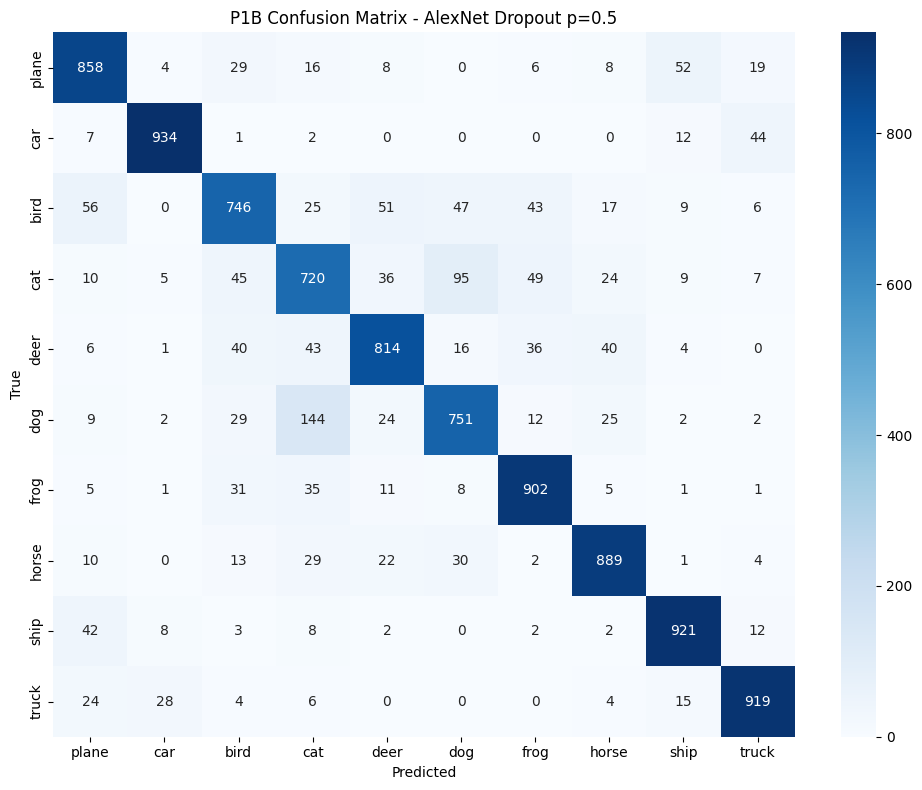


=== P1 Summary ===
  Baseline (p=0):  87.17%
  Dropout p=0.3:   86.82%
  Dropout p=0.5:   84.54%


In [6]:

# ============================================================
# PROBLEM 1B: AlexNet with Dropout (p=0.3 and p=0.5)
# ============================================================
print('Training P1B: Modified AlexNet with Dropout p=0.3')
alexnet_d03 = ModifiedAlexNet(dropout_p=0.3).to(device)
p1b03_tl, p1b03_vl, p1b03_va, _ = train_model(
    alexnet_d03, train_loader, val_loader,
    n_epochs=30, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p1b03_test = evaluate(alexnet_d03, test_loader, nn.CrossEntropyLoss(), device)
print(f'P1B (p=0.3) Test Acc: {p1b03_test:.2f}%')

print('\nTraining P1B: Modified AlexNet with Dropout p=0.5')
alexnet_d05 = ModifiedAlexNet(dropout_p=0.5).to(device)
p1b05_tl, p1b05_vl, p1b05_va, _ = train_model(
    alexnet_d05, train_loader, val_loader,
    n_epochs=30, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p1b05_test = evaluate(alexnet_d05, test_loader, nn.CrossEntropyLoss(), device)
print(f'P1B (p=0.5) Test Acc: {p1b05_test:.2f}%')

# Compare all three AlexNet variants
plot_curves(
    [p1a_tl, p1b03_tl, p1b05_tl],
    [p1a_vl, p1b03_vl, p1b05_vl],
    [p1a_va, p1b03_va, p1b05_va],
    'P1B: AlexNet - Baseline vs Dropout Comparison',
    labels=['Baseline (p=0)', 'Dropout p=0.3', 'Dropout p=0.5']
)

p1b03_preds, _ = get_all_preds(alexnet_d03, test_loader, device)
plot_confusion_matrix(p1b03_preds, p1a_labels, CLASSES, 'P1B Confusion Matrix - AlexNet Dropout p=0.3')

p1b05_preds, _ = get_all_preds(alexnet_d05, test_loader, device)
plot_confusion_matrix(p1b05_preds, p1a_labels, CLASSES, 'P1B Confusion Matrix - AlexNet Dropout p=0.5')

print('\n=== P1 Summary ===')
print(f'  Baseline (p=0):  {p1a_test_acc:.2f}%')
print(f'  Dropout p=0.3:   {p1b03_test:.2f}%')
print(f'  Dropout p=0.5:   {p1b05_test:.2f}%')

In [7]:

# ============================================================
# PROBLEM 2A: Modified VGGNet for CIFAR-10
# ============================================================
# VGG configurations: A=VGG-11, B=VGG-13, D=VGG-16, E=VGG-19
# We choose VGG-11 adapted to match our AlexNet param count (~5.5M)
# Modifications for 32x32 CIFAR-10:
# 1. Reduce MaxPool from 5 to 3 (keeping 3 pool layers: 32->16->8->4)
# 2. FC layers: 4096->4096->1000 -> 512->256->10
# 3. All 3x3 conv kernels kept (VGG's core design)

VGG_CFGS = {
    'VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512],  # 3 pool layers for 32x32
}

class AdaptedVGG(nn.Module):
    def __init__(self, cfg_name='VGG11', dropout_p=0.0):
        super(AdaptedVGG, self).__init__()
        cfg = VGG_CFGS[cfg_name]
        layers = []
        in_ch = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                layers += [nn.Conv2d(in_ch, v, kernel_size=3, padding=1),
                           nn.ReLU(inplace=True)]
                in_ch = v
        self.features = nn.Sequential(*layers)
        # After 3 MaxPools: 32->16->8->4, 512 channels -> 512*4*4=8192
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(512 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

vgg_base = AdaptedVGG('VGG11', dropout_p=0.0).to(device)
print('=== Adapted VGG-11 for CIFAR-10 ===')
summary(vgg_base, (3, 32, 32))

=== Adapted VGG-11 for CIFAR-10 ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         590,080
             ReLU-10            [-1, 256, 8, 8]               0
        MaxPool2d-11            [-1, 256, 4, 4]               0
           Conv2d-12            [-1, 512, 4, 4]       1,180,160
             ReLU-13            [-1, 512, 4, 4]               0
   

Training P2A: Adapted VGG-11 - Baseline (no dropout), 30 epochs
Epoch   1/30 | T-Loss: 2.1489 T-Acc: 16.99% | V-Loss: 1.8809 V-Acc: 28.90%
Epoch   5/30 | T-Loss: 1.2375 T-Acc: 56.53% | V-Loss: 1.1111 V-Acc: 60.62%
Epoch  10/30 | T-Loss: 0.8435 T-Acc: 71.64% | V-Loss: 0.7300 V-Acc: 75.38%
Epoch  15/30 | T-Loss: 0.6005 T-Acc: 79.88% | V-Loss: 0.6676 V-Acc: 77.72%
Epoch  20/30 | T-Loss: 0.4141 T-Acc: 85.67% | V-Loss: 0.4829 V-Acc: 83.86%
Epoch  25/30 | T-Loss: 0.2421 T-Acc: 91.63% | V-Loss: 0.3838 V-Acc: 87.48%
Epoch  30/30 | T-Loss: 0.1570 T-Acc: 94.70% | V-Loss: 0.3573 V-Acc: 88.64%

Training complete in 2.1 min | Best Val Acc: 88.78%
Time per epoch: 4.1s

P2A Test Accuracy: 88.64%


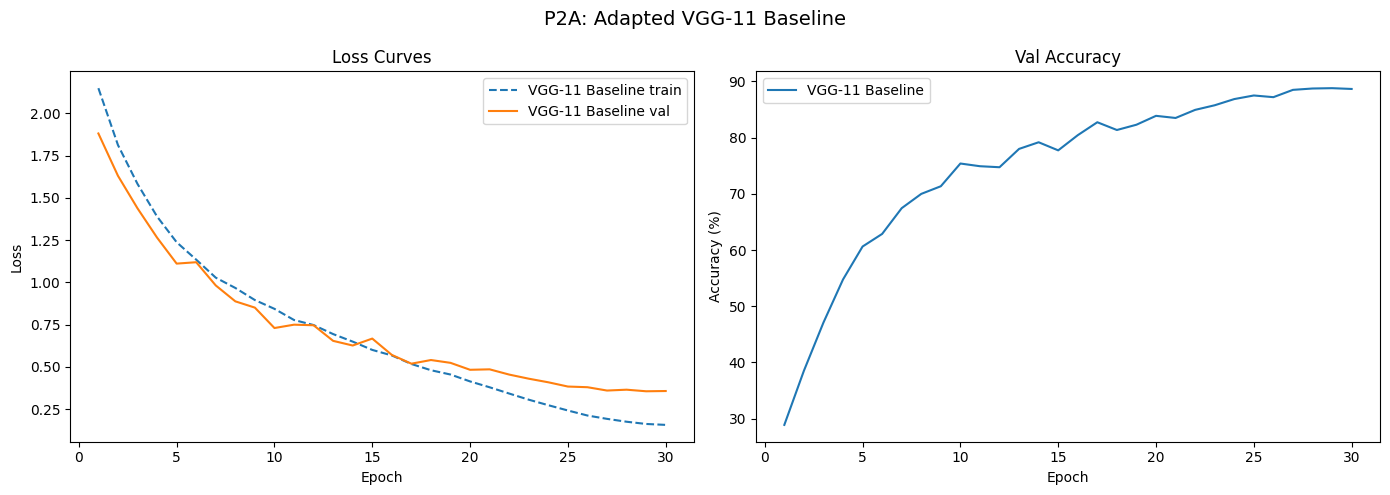

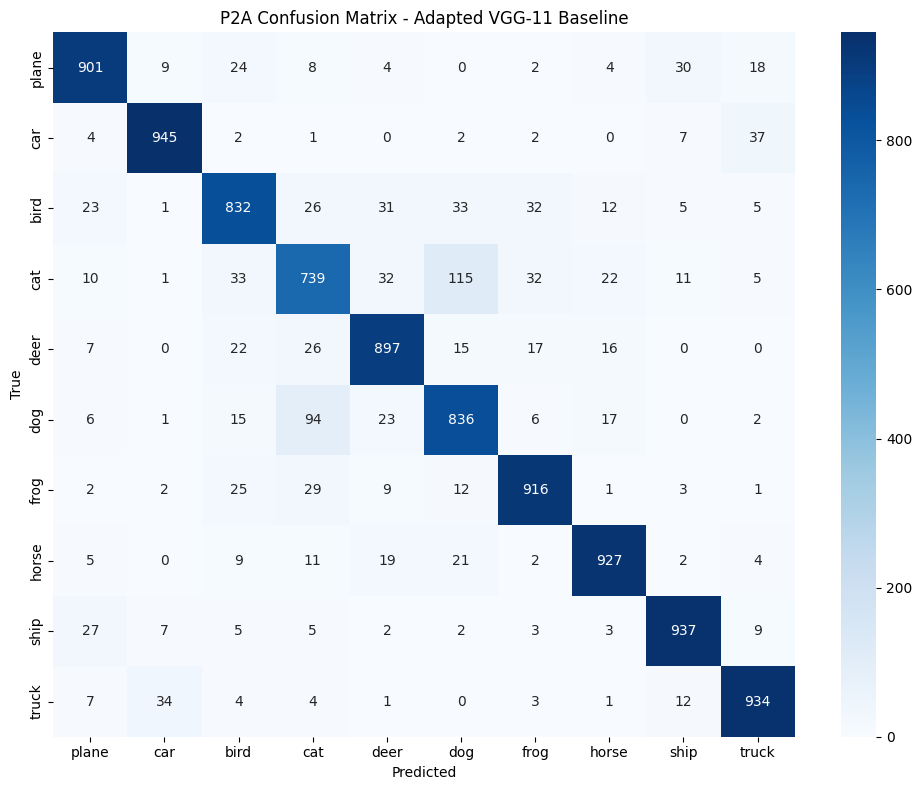

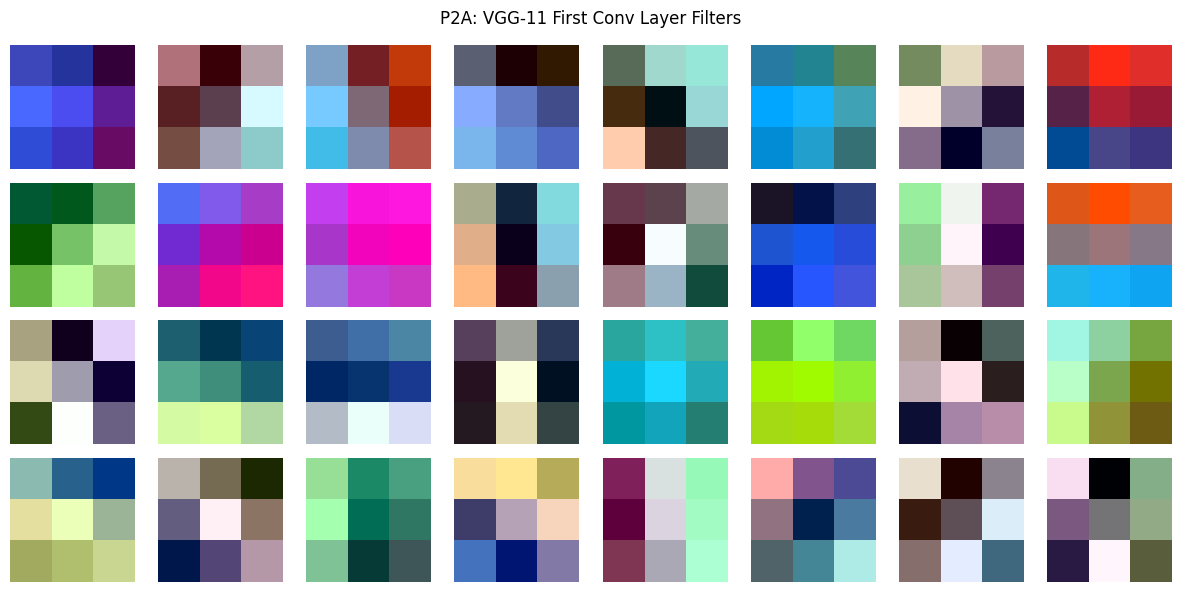


=== AlexNet vs VGGNet Architecture Comparison ===
  Modified AlexNet - Test Acc: 87.17% | Time/epoch: 4.1s
  Adapted VGG-11   - Test Acc: 88.64% | Time/epoch: 4.1s


In [8]:

# ============================================================
# PROBLEM 2A: Train VGG-11 baseline
# ============================================================
print('Training P2A: Adapted VGG-11 - Baseline (no dropout), 30 epochs')
vgg_base = AdaptedVGG('VGG11', dropout_p=0.0).to(device)
p2a_tl, p2a_vl, p2a_va, p2a_time = train_model(
    vgg_base, train_loader, val_loader,
    n_epochs=30, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)

crit = nn.CrossEntropyLoss()
_, p2a_test_acc = evaluate(vgg_base, test_loader, crit, device)
print(f'\nP2A Test Accuracy: {p2a_test_acc:.2f}%')

plot_curves([p2a_tl], [p2a_vl], [p2a_va],
            'P2A: Adapted VGG-11 Baseline', labels=['VGG-11 Baseline'])

p2a_preds, p2a_labels = get_all_preds(vgg_base, test_loader, device)
plot_confusion_matrix(p2a_preds, p2a_labels, CLASSES, 'P2A Confusion Matrix - Adapted VGG-11 Baseline')

visualize_first_layer_filters(vgg_base, vgg_base.features[0],
                               'P2A: VGG-11 First Conv Layer Filters')

# AlexNet vs VGGNet comparison
print('\n=== AlexNet vs VGGNet Architecture Comparison ===')
print(f'  Modified AlexNet - Test Acc: {p1a_test_acc:.2f}% | Time/epoch: {p1a_time/30:.1f}s')
print(f'  Adapted VGG-11   - Test Acc: {p2a_test_acc:.2f}% | Time/epoch: {p2a_time/30:.1f}s')

Training P2B: VGG-11 Dropout p=0.3
Epoch   1/30 | T-Loss: 2.0468 T-Acc: 20.80% | V-Loss: 1.7750 V-Acc: 29.96%
Epoch   5/30 | T-Loss: 1.1640 T-Acc: 59.66% | V-Loss: 1.1028 V-Acc: 61.54%
Epoch  10/30 | T-Loss: 0.8212 T-Acc: 72.85% | V-Loss: 0.7370 V-Acc: 75.52%
Epoch  15/30 | T-Loss: 0.5937 T-Acc: 80.31% | V-Loss: 0.5735 V-Acc: 80.58%
Epoch  20/30 | T-Loss: 0.3913 T-Acc: 86.88% | V-Loss: 0.4534 V-Acc: 84.56%
Epoch  25/30 | T-Loss: 0.2257 T-Acc: 92.39% | V-Loss: 0.3763 V-Acc: 87.80%
Epoch  30/30 | T-Loss: 0.1454 T-Acc: 95.06% | V-Loss: 0.3407 V-Acc: 89.34%

Training complete in 2.0 min | Best Val Acc: 89.50%
Time per epoch: 4.1s
P2B VGG p=0.3 Test Acc: 89.05%

Training P2B: VGG-11 Dropout p=0.5
Epoch   1/30 | T-Loss: 2.0734 T-Acc: 19.57% | V-Loss: 1.9466 V-Acc: 23.00%
Epoch   5/30 | T-Loss: 1.2698 T-Acc: 55.54% | V-Loss: 1.1439 V-Acc: 59.22%
Epoch  10/30 | T-Loss: 0.9090 T-Acc: 69.99% | V-Loss: 0.8241 V-Acc: 73.06%
Epoch  15/30 | T-Loss: 0.6671 T-Acc: 78.12% | V-Loss: 0.7444 V-Acc: 75.78%

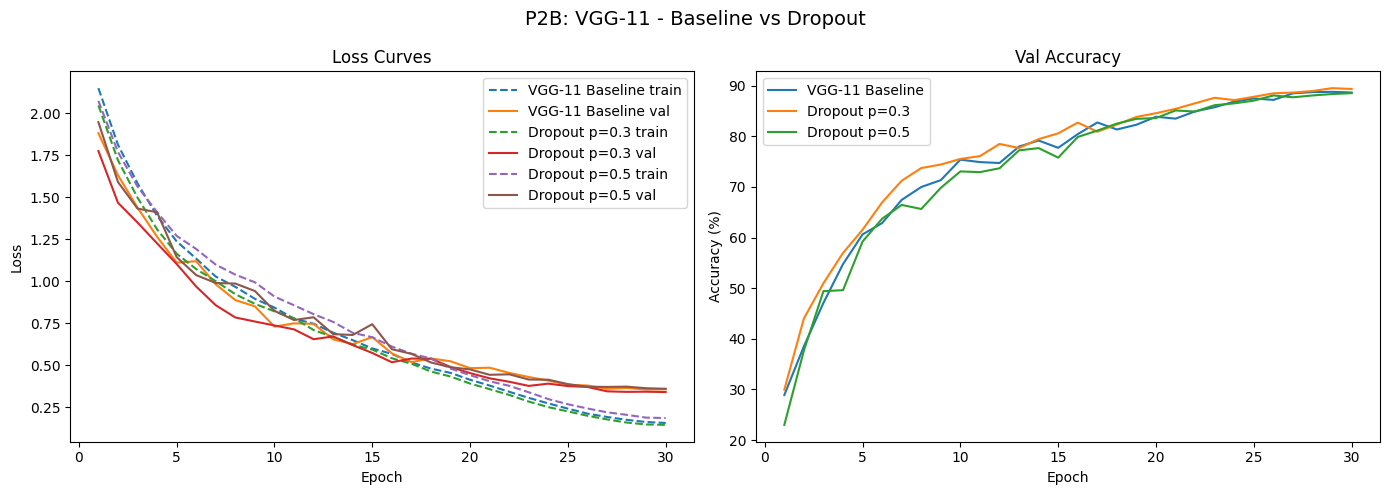


=== P2 Summary ===
  VGG Baseline:    88.64%
  VGG p=0.3:       89.05%
  VGG p=0.5:       88.53%
=== ResNet-11 for CIFAR-10 ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
            Conv2d-6           [-1, 64, 32, 32]          36,864
       BatchNorm2d-7           [-1, 64, 32, 32]             128
        BasicBlock-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 16, 16]          73,728
      BatchNorm2d-10          [-1, 128, 16, 16]             256
           Conv2d-11          [-1, 128, 16, 16]         147,456
      BatchNorm2d-12          [-1, 128

In [9]:

# ============================================================
# PROBLEM 2B: VGG-11 with Dropout
# ============================================================
print('Training P2B: VGG-11 Dropout p=0.3')
vgg_d03 = AdaptedVGG('VGG11', dropout_p=0.3).to(device)
p2b03_tl, p2b03_vl, p2b03_va, _ = train_model(
    vgg_d03, train_loader, val_loader,
    n_epochs=30, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p2b03_test = evaluate(vgg_d03, test_loader, nn.CrossEntropyLoss(), device)
print(f'P2B VGG p=0.3 Test Acc: {p2b03_test:.2f}%')

print('\nTraining P2B: VGG-11 Dropout p=0.5')
vgg_d05 = AdaptedVGG('VGG11', dropout_p=0.5).to(device)
p2b05_tl, p2b05_vl, p2b05_va, _ = train_model(
    vgg_d05, train_loader, val_loader,
    n_epochs=30, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p2b05_test = evaluate(vgg_d05, test_loader, nn.CrossEntropyLoss(), device)
print(f'P2B VGG p=0.5 Test Acc: {p2b05_test:.2f}%')

plot_curves(
    [p2a_tl, p2b03_tl, p2b05_tl],
    [p2a_vl, p2b03_vl, p2b05_vl],
    [p2a_va, p2b03_va, p2b05_va],
    'P2B: VGG-11 - Baseline vs Dropout',
    labels=['VGG-11 Baseline', 'Dropout p=0.3', 'Dropout p=0.5']
)

print('\n=== P2 Summary ===')
print(f'  VGG Baseline:    {p2a_test_acc:.2f}%')
print(f'  VGG p=0.3:       {p2b03_test:.2f}%')
print(f'  VGG p=0.5:       {p2b05_test:.2f}%')
# ============================================================
# PROBLEM 3: ResNet-11 and ResNet-18 for CIFAR-10
# ============================================================

class BasicBlock(nn.Module):
    """Standard BasicBlock with BN: conv->BN->ReLU->conv->BN + skip"""
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)


class ResNetCIFAR(nn.Module):
    """Flexible ResNet for CIFAR-10 (32x32 input, single 3x3 stem, no initial pool)"""
    def __init__(self, block, stage_layers, dropout_p=0.0):
        """
        stage_layers: list of (planes, n_blocks, stride) per stage
        """
        super(ResNetCIFAR, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        layers = []
        in_planes = 64
        for planes, n_blocks, stride in stage_layers:
            layers.append(block(in_planes, planes, stride=stride))
            in_planes = planes
            for _ in range(1, n_blocks):
                layers.append(block(in_planes, planes, stride=1))
        self.layers = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(in_planes, 10)

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def resnet11_cifar(dropout_p=0.0):
    """ResNet-11: 4 stages with 1 BasicBlock each (1+2+2+2+2+2 = ~11 weight layers)"""
    return ResNetCIFAR(BasicBlock, [
        (64,  1, 1),
        (128, 1, 2),
        (256, 1, 2),
        (512, 1, 2),
    ], dropout_p=dropout_p)


def resnet18_cifar(dropout_p=0.0):
    """ResNet-18: 4 stages with 2 BasicBlocks each"""
    return ResNetCIFAR(BasicBlock, [
        (64,  2, 1),
        (128, 2, 2),
        (256, 2, 2),
        (512, 2, 2),
    ], dropout_p=dropout_p)


print('=== ResNet-11 for CIFAR-10 ===')
resnet11 = resnet11_cifar().to(device)
summary(resnet11, (3, 32, 32))

print('\n=== ResNet-18 for CIFAR-10 ===')
resnet18 = resnet18_cifar().to(device)
summary(resnet18, (3, 32, 32))

Training P3A: ResNet-11 Baseline, 50 epochs
Epoch   1/50 | T-Loss: 1.6725 T-Acc: 38.45% | V-Loss: 1.9370 V-Acc: 37.98%
Epoch   5/50 | T-Loss: 0.7000 T-Acc: 75.50% | V-Loss: 0.7530 V-Acc: 73.38%
Epoch  10/50 | T-Loss: 0.4932 T-Acc: 82.99% | V-Loss: 0.5812 V-Acc: 80.24%
Epoch  15/50 | T-Loss: 0.4105 T-Acc: 85.85% | V-Loss: 0.5887 V-Acc: 80.16%
Epoch  20/50 | T-Loss: 0.3542 T-Acc: 87.83% | V-Loss: 0.4528 V-Acc: 85.00%
Epoch  25/50 | T-Loss: 0.2888 T-Acc: 89.94% | V-Loss: 0.5670 V-Acc: 81.26%
Epoch  30/50 | T-Loss: 0.2265 T-Acc: 92.09% | V-Loss: 0.3577 V-Acc: 88.24%
Epoch  35/50 | T-Loss: 0.1513 T-Acc: 94.91% | V-Loss: 0.3854 V-Acc: 88.52%
Epoch  40/50 | T-Loss: 0.0713 T-Acc: 97.73% | V-Loss: 0.2312 V-Acc: 92.70%
Epoch  45/50 | T-Loss: 0.0322 T-Acc: 99.15% | V-Loss: 0.2145 V-Acc: 93.24%
Epoch  50/50 | T-Loss: 0.0225 T-Acc: 99.56% | V-Loss: 0.2091 V-Acc: 93.46%

Training complete in 3.3 min | Best Val Acc: 93.68%
Time per epoch: 3.9s

P3A ResNet-11 Test Acc: 93.35%

Training P3A: ResNet-18 

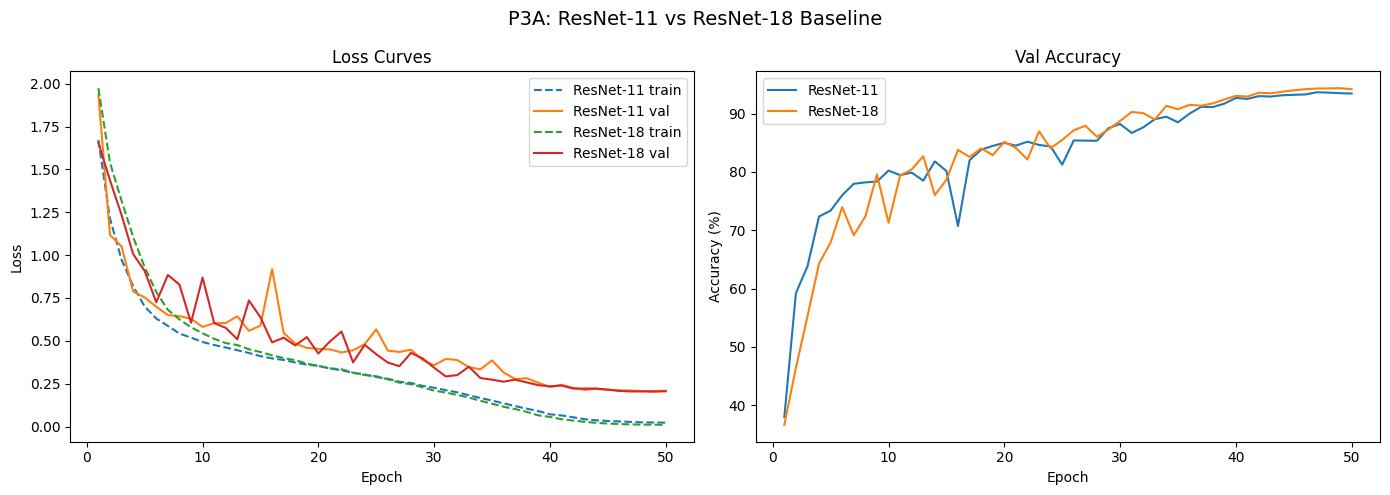

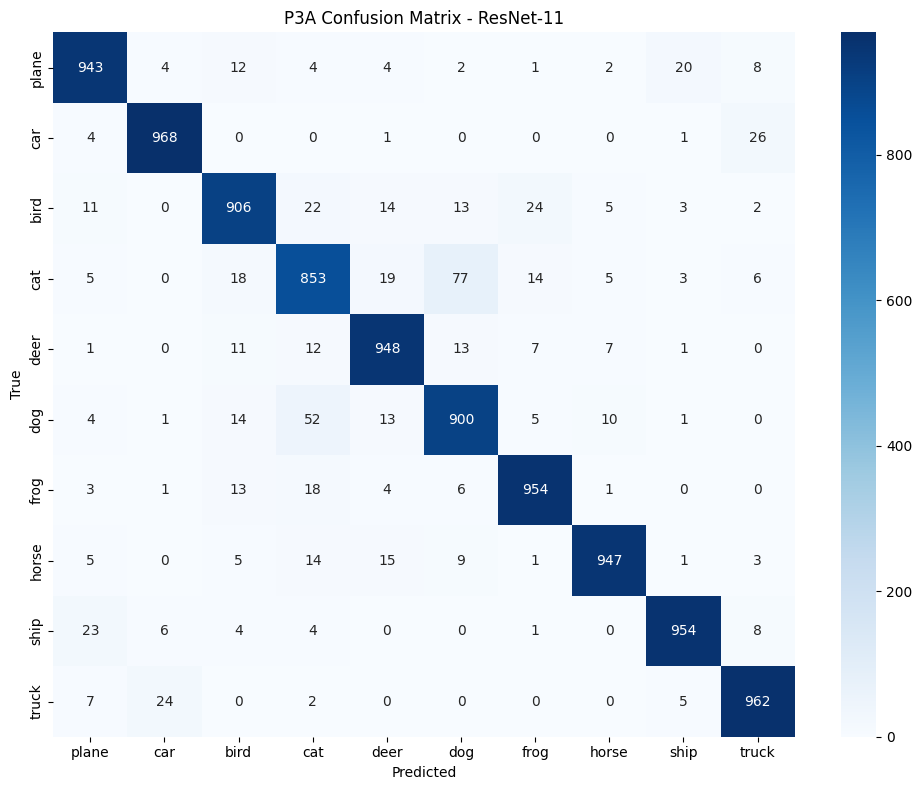

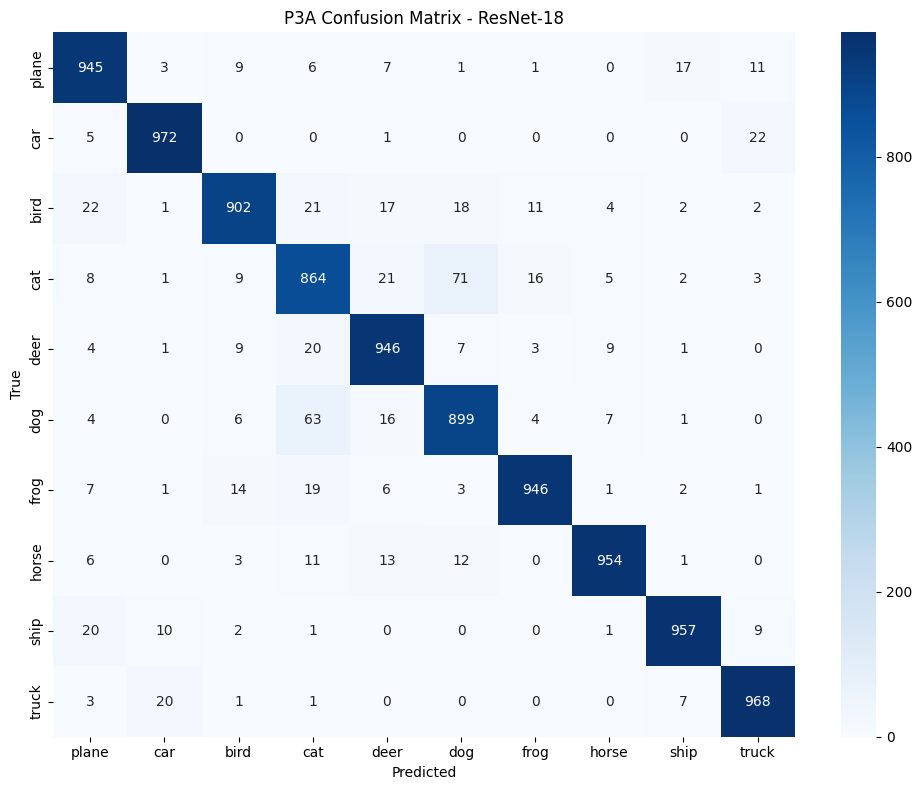


ResNet-11: 93.35% | 3.9s/epoch
ResNet-18: 93.53% | 3.9s/epoch


In [10]:

# ============================================================
# PROBLEM 3A: Train ResNet-11 and ResNet-18 (50 epochs)
# ============================================================
print('Training P3A: ResNet-11 Baseline, 50 epochs')
resnet11 = resnet11_cifar(dropout_p=0.0).to(device)
p3a11_tl, p3a11_vl, p3a11_va, p3a11_time = train_model(
    resnet11, train_loader, val_loader,
    n_epochs=50, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p3a11_test = evaluate(resnet11, test_loader, nn.CrossEntropyLoss(), device)
print(f'\nP3A ResNet-11 Test Acc: {p3a11_test:.2f}%')

print('\nTraining P3A: ResNet-18 Baseline, 50 epochs')
resnet18 = resnet18_cifar(dropout_p=0.0).to(device)
p3a18_tl, p3a18_vl, p3a18_va, p3a18_time = train_model(
    resnet18, train_loader, val_loader,
    n_epochs=50, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p3a18_test = evaluate(resnet18, test_loader, nn.CrossEntropyLoss(), device)
print(f'\nP3A ResNet-18 Test Acc: {p3a18_test:.2f}%')

# Plot
plot_curves(
    [p3a11_tl, p3a18_tl],
    [p3a11_vl, p3a18_vl],
    [p3a11_va, p3a18_va],
    'P3A: ResNet-11 vs ResNet-18 Baseline',
    labels=['ResNet-11', 'ResNet-18']
)

p3a11_preds, p3a_labels = get_all_preds(resnet11, test_loader, device)
plot_confusion_matrix(p3a11_preds, p3a_labels, CLASSES, 'P3A Confusion Matrix - ResNet-11')

p3a18_preds, _ = get_all_preds(resnet18, test_loader, device)
plot_confusion_matrix(p3a18_preds, p3a_labels, CLASSES, 'P3A Confusion Matrix - ResNet-18')

print(f'\nResNet-11: {p3a11_test:.2f}% | {p3a11_time/50:.1f}s/epoch')
print(f'ResNet-18: {p3a18_test:.2f}% | {p3a18_time/50:.1f}s/epoch')

Training P3B: ResNet-11 + Dropout p=0.3
Epoch   1/50 | T-Loss: 1.7428 T-Acc: 36.21% | V-Loss: 1.4598 V-Acc: 47.74%
Epoch   5/50 | T-Loss: 0.7347 T-Acc: 74.20% | V-Loss: 0.8687 V-Acc: 70.66%
Epoch  10/50 | T-Loss: 0.5151 T-Acc: 82.33% | V-Loss: 0.6352 V-Acc: 78.96%
Epoch  15/50 | T-Loss: 0.4312 T-Acc: 85.20% | V-Loss: 0.4606 V-Acc: 84.18%
Epoch  20/50 | T-Loss: 0.3667 T-Acc: 87.38% | V-Loss: 0.4739 V-Acc: 84.02%
Epoch  25/50 | T-Loss: 0.3014 T-Acc: 89.66% | V-Loss: 0.4336 V-Acc: 86.12%
Epoch  30/50 | T-Loss: 0.2410 T-Acc: 91.74% | V-Loss: 0.3796 V-Acc: 87.58%
Epoch  35/50 | T-Loss: 0.1664 T-Acc: 94.26% | V-Loss: 0.3027 V-Acc: 90.04%
Epoch  40/50 | T-Loss: 0.0819 T-Acc: 97.34% | V-Loss: 0.2778 V-Acc: 91.10%
Epoch  45/50 | T-Loss: 0.0376 T-Acc: 98.97% | V-Loss: 0.2268 V-Acc: 92.96%
Epoch  50/50 | T-Loss: 0.0259 T-Acc: 99.44% | V-Loss: 0.2238 V-Acc: 93.16%

Training complete in 3.3 min | Best Val Acc: 93.24%
Time per epoch: 3.9s
RN11 p=0.3 Test: 93.34%

Training P3B: ResNet-11 + Dropout p=

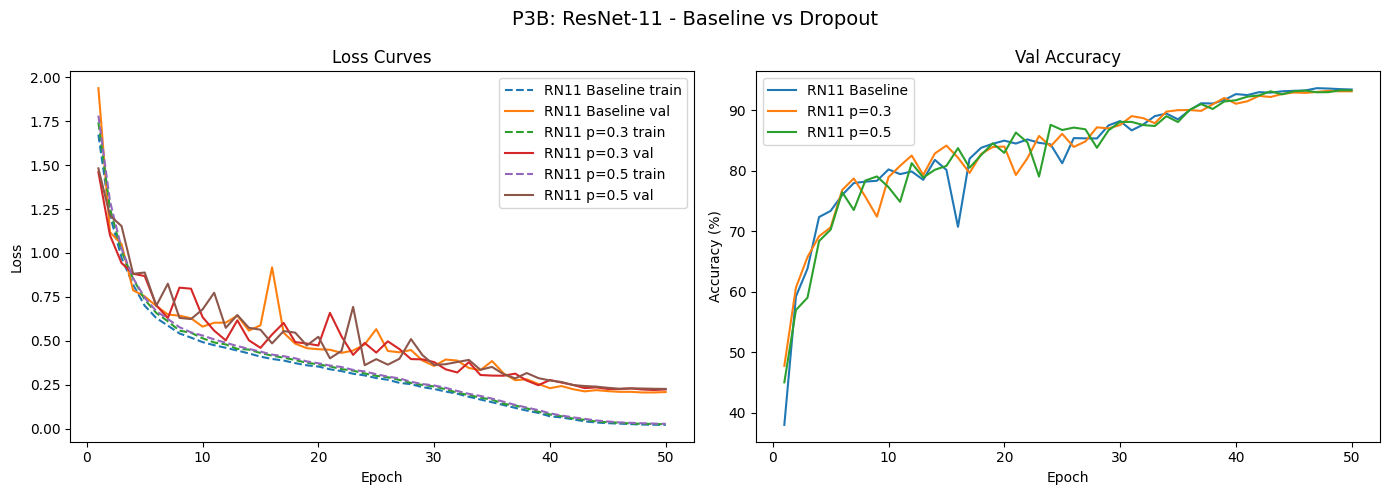

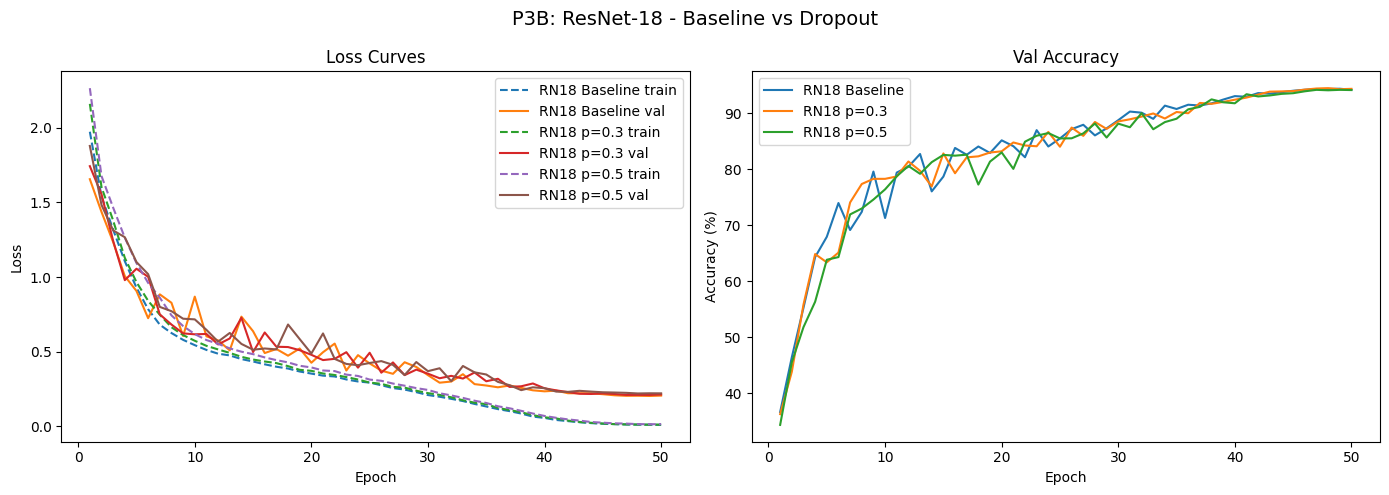

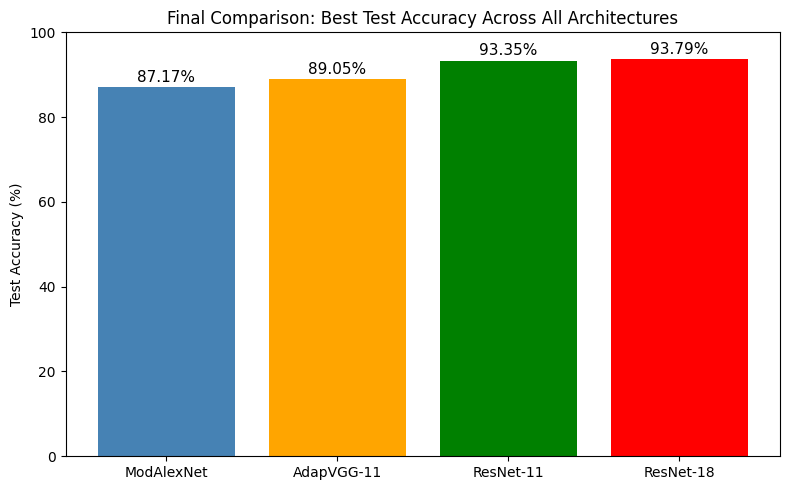


========== FINAL SUMMARY ==========
  Best AlexNet:   87.17%
  Best VGG-11:    89.05%
  Best ResNet-11: 93.35%
  Best ResNet-18: 93.79%

Hardware: cuda
Batch size: 128, Seed: 42


In [11]:

# ============================================================
# PROBLEM 3B: ResNet Dropout + Final Grand Comparison
# ============================================================
print('Training P3B: ResNet-11 + Dropout p=0.3')
rn11_d03 = resnet11_cifar(dropout_p=0.3).to(device)
p3b11d03_tl, p3b11d03_vl, p3b11d03_va, _ = train_model(
    rn11_d03, train_loader, val_loader,
    n_epochs=50, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p3b11d03_test = evaluate(rn11_d03, test_loader, nn.CrossEntropyLoss(), device)
print(f'RN11 p=0.3 Test: {p3b11d03_test:.2f}%')

print('\nTraining P3B: ResNet-11 + Dropout p=0.5')
rn11_d05 = resnet11_cifar(dropout_p=0.5).to(device)
p3b11d05_tl, p3b11d05_vl, p3b11d05_va, _ = train_model(
    rn11_d05, train_loader, val_loader,
    n_epochs=50, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p3b11d05_test = evaluate(rn11_d05, test_loader, nn.CrossEntropyLoss(), device)
print(f'RN11 p=0.5 Test: {p3b11d05_test:.2f}%')

print('\nTraining P3B: ResNet-18 + Dropout p=0.3')
rn18_d03 = resnet18_cifar(dropout_p=0.3).to(device)
p3b18d03_tl, p3b18d03_vl, p3b18d03_va, _ = train_model(
    rn18_d03, train_loader, val_loader,
    n_epochs=50, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p3b18d03_test = evaluate(rn18_d03, test_loader, nn.CrossEntropyLoss(), device)
print(f'RN18 p=0.3 Test: {p3b18d03_test:.2f}%')

print('\nTraining P3B: ResNet-18 + Dropout p=0.5')
rn18_d05 = resnet18_cifar(dropout_p=0.5).to(device)
p3b18d05_tl, p3b18d05_vl, p3b18d05_va, _ = train_model(
    rn18_d05, train_loader, val_loader,
    n_epochs=50, lr=0.1, weight_decay=5e-4, scheduler_type='cosine', device=device
)
_, p3b18d05_test = evaluate(rn18_d05, test_loader, nn.CrossEntropyLoss(), device)
print(f'RN18 p=0.5 Test: {p3b18d05_test:.2f}%')

plot_curves(
    [p3a11_tl, p3b11d03_tl, p3b11d05_tl],
    [p3a11_vl, p3b11d03_vl, p3b11d05_vl],
    [p3a11_va, p3b11d03_va, p3b11d05_va],
    'P3B: ResNet-11 - Baseline vs Dropout',
    labels=['RN11 Baseline', 'RN11 p=0.3', 'RN11 p=0.5']
)
plot_curves(
    [p3a18_tl, p3b18d03_tl, p3b18d05_tl],
    [p3a18_vl, p3b18d03_vl, p3b18d05_vl],
    [p3a18_va, p3b18d03_va, p3b18d05_va],
    'P3B: ResNet-18 - Baseline vs Dropout',
    labels=['RN18 Baseline', 'RN18 p=0.3', 'RN18 p=0.5']
)

# ============================================================
# FINAL GRAND COMPARISON (best variants of each architecture)
# ============================================================
best_alex  = max(p1a_test_acc, p1b03_test, p1b05_test)
best_vgg   = max(p2a_test_acc, p2b03_test, p2b05_test)
best_rn11  = max(p3a11_test, p3b11d03_test, p3b11d05_test)
best_rn18  = max(p3a18_test, p3b18d03_test, p3b18d05_test)

names  = ['ModAlexNet', 'AdapVGG-11', 'ResNet-11', 'ResNet-18']
scores = [best_alex, best_vgg, best_rn11, best_rn18]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, scores, color=['steelblue','orange','green','red'])
ax.set_ylim(0, 100); ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Final Comparison: Best Test Accuracy Across All Architectures')
for bar, val in zip(bars, scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()

print('\n========== FINAL SUMMARY ==========')
print(f'  Best AlexNet:   {best_alex:.2f}%')
print(f'  Best VGG-11:    {best_vgg:.2f}%')
print(f'  Best ResNet-11: {best_rn11:.2f}%')
print(f'  Best ResNet-18: {best_rn18:.2f}%')
print('\nHardware:', device)
print(f'Batch size: {BATCH_SIZE}, Seed: {SEED}')